# 4.1.7 Průzkumná analýza dat

Jednoduchý notebook pro základní průzkumnou analýzu dat před nahráním do databáze.


In [56]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

for _ in range(5):
    if (PROJECT_ROOT / "docs").exists() and (PROJECT_ROOT / "data").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/adelaleppeltova/firesport-app


In [60]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 1.8 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 1.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 2.8 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Načtení dat


In [61]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from docs.analysis import (
    add_quality_flags,
    find_inconsistent_team_names,
    find_missing_attempts,
    find_possible_duplicate_athletes,
    get_competitions,
    get_results,
    load_json_files_from_dir,
    results_to_dataframe,
    summarize_data_quality,
    summarize_dataset,
    summarize_final_times,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


In [62]:
# Pokud jsou JSON soubory jinde, upravte cestu zde.
DATA_DIR = PROJECT_ROOT / "data"

records = load_json_files_from_dir(DATA_DIR)
competitions = get_competitions(records)
results = get_results(records)

df_competitions = pd.DataFrame(competitions)
df_results = add_quality_flags(results_to_dataframe(results))

valid_results = df_results.loc[
    (df_results["final_status"] == "valid")
    & df_results["final_time"].notna()
    & ~df_results["suspicious_final_time"]
].copy()

df_results["year"] = df_results["competition_date"].dt.year
df_results["month"] = df_results["competition_date"].dt.month
df_results["year_month"] = df_results["competition_date"].dt.to_period("M").astype(str)

len(records), len(df_competitions), len(df_results)


(329, 329, 13854)

## Charakteristika datasetu


In [63]:
dataset_summary = summarize_dataset(df_results)
pd.Series(dataset_summary)


athlete_count              4708
result_count              13854
competition_count            65
min_date             2019-05-04
max_date             2025-10-04
disciplines              [100m]
dtype: object

In [64]:
df_results[[
    "competition_date",
    "competition_name",
    "category_name",
    "discipline",
    "athlete_full_name",
    "team",
    "final_time",
    "final_status",
]].head(10)


,competition_date,competition_name,category_name,discipline,athlete_full_name,team,final_time,final_status
0,2019-06-02,Běloveský kilo,Muži,100m,Patrik Kligl,Běloves,15.43,valid
1,2019-06-02,Běloveský kilo,Muži,100m,Lukáš Kroupa,Kvasiny B,16.01,valid
2,2019-06-02,Běloveský kilo,Muži,100m,Jan Zhříval,HZS Hradec Králové,16.13,valid
3,2019-06-02,Běloveský kilo,Muži,100m,Michal Gierlowski,Tuř,17.34,valid
4,2019-06-02,Běloveský kilo,Muži,100m,Pavel Hoffman,Běloves,17.52,valid
5,2019-06-02,Běloveský kilo,Muži,100m,David Hoffman,Běloves,17.59,valid
6,2019-06-02,Běloveský kilo,Muži,100m,Dominik Mašek,Ruda,17.68,valid
7,2019-06-02,Běloveský kilo,Muži,100m,Jakub Vondra,Stolín,18.19,valid
8,2019-06-02,Běloveský kilo,Muži,100m,Stanislav Pavlas,Vidochov,18.63,valid
9,2019-06-02,Běloveský kilo,Muži,100m,Lukáš Kligl,Běloves,18.72,valid


## Základní statistické ukazatele


In [65]:
final_time_summary = summarize_final_times(df_results)
pd.Series(final_time_summary)


mean     20.27
median   19.72
min      14.64
max      57.13
std       2.92
dtype: float64

## Distribuce dat

Tato část ukazuje rozdělení výsledků, zastoupení kategorií a jednoduchou identifikaci odlehlých hodnot.


In [66]:
histogram_table = (
    pd.cut(valid_results["final_time"], bins=10)
    .value_counts()
    .sort_index()
    .rename_axis("time_interval")
    .reset_index(name="result_count")
)

histogram_table


,time_interval,result_count
0,"(14.598, 18.889]",4479
1,"(18.889, 23.138]",7325
2,"(23.138, 27.387]",1159
3,"(27.387, 31.636]",248
4,"(31.636, 35.885]",72
5,"(35.885, 40.134]",31
6,"(40.134, 44.383]",11
7,"(44.383, 48.632]",1
8,"(48.632, 52.881]",3
9,"(52.881, 57.13]",1


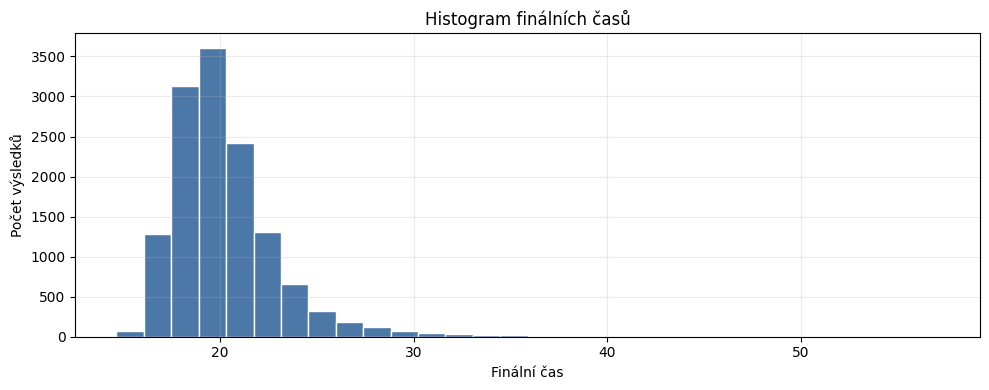

In [67]:
ax = valid_results["final_time"].plot(
    kind="hist",
    bins=30,
    color="#4C78A8",
    edgecolor="white",
)
ax.set_title("Histogram finálních časů")
ax.set_xlabel("Finální čas")
ax.set_ylabel("Počet výsledků")
plt.tight_layout()
plt.show()


In [68]:
category_distribution = (
    df_results.groupby(["category_name", "discipline"])
    .size()
    .reset_index(name="result_count")
    .sort_values("result_count", ascending=False)
)

category_distribution.head(20)


,category_name,discipline,result_count
4,Muži,100m,2182
11,Ženy,100m,2059
10,Střední dorostenky,100m,1460
9,Střední dorostenci,100m,1446
3,Mladší dorostenky,100m,1102
7,Starší dorostenci,100m,855
8,Starší dorostenky,100m,838
1,Dorostenky,100m,735
2,Mladší dorostenci,100m,730
0,Dorostenci,100m,683


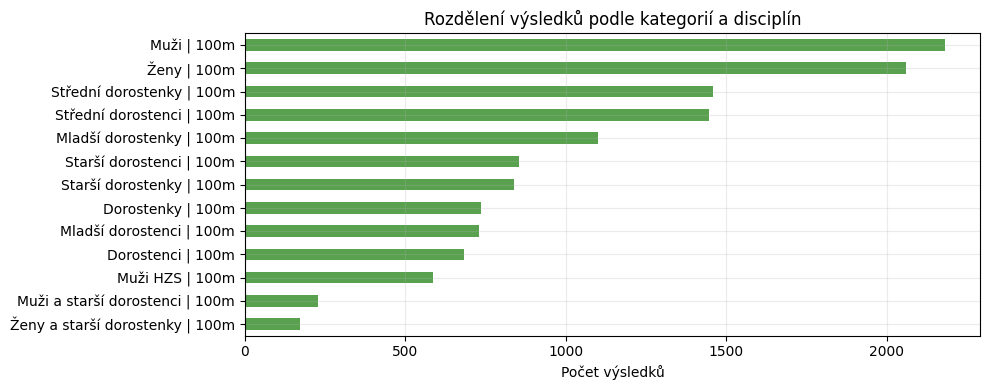

In [69]:
top_categories = category_distribution.head(15).copy()
top_categories["label"] = top_categories["category_name"] + " | " + top_categories["discipline"]

ax = top_categories.sort_values("result_count").plot(
    kind="barh",
    x="label",
    y="result_count",
    color="#59A14F",
    legend=False,
)
ax.set_title("Rozdělení výsledků podle kategorií a disciplín")
ax.set_xlabel("Počet výsledků")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [70]:
q1 = valid_results["final_time"].quantile(0.25)
q3 = valid_results["final_time"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = valid_results.loc[
    (valid_results["final_time"] < lower_bound)
    | (valid_results["final_time"] > upper_bound),
    [
        "competition_date",
        "competition_name",
        "category_name",
        "discipline",
        "athlete_full_name",
        "team",
        "final_time",
    ],
].sort_values("final_time")

pd.Series({
    "q1": q1,
    "q3": q3,
    "iqr": iqr,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound,
    "outlier_count": len(outliers),
})


q1               18.41
q3               21.35
iqr               2.94
lower_bound      14.00
upper_bound      25.76
outlier_count   583.00
dtype: float64

In [71]:
outliers.head(20)


,competition_date,competition_name,category_name,discipline,athlete_full_name,team,final_time
8965,2023-08-26,Mistrovství České republiky v požárním sportu družstev SDH a HZS ČR – Sokolov,Ženy,100m,Kateřina KADLECOVÁ,Hlinsko,25.77
12826,2025-04-26,Dubenecké stovky 2025,Mladší dorostenky,100m,Anna Záveská,Radvanice,25.77
9075,2023-09-24,Zbožnovská stovka,Starší dorostenky,100m,Petra Bartošová,Čeperka,25.79
2647,2020-06-27,"O pohár HVP, a.s.",Muži a starší dorostenci,100m,Richard Vašíček,Horní Slavkov,25.80
8966,2023-08-26,Mistrovství České republiky v požárním sportu družstev SDH a HZS ČR – Sokolov,Ženy,100m,Veronika LEVÁKOVÁ,Zahořany,25.80
9646,2024-08-03,Večerní stovka,Mladší dorostenky,100m,Rozálie Kučerová,Lezník,25.80
7321,2023-07-09,Stovkování pod Slunečnou,Mladší dorostenci,100m,Jaroslav Neudert,Želivsko,25.81
4232,2021-07-03,MČR dorostu v PS,Dorostenky,100m,Barbora Machová,Oltyně,25.81
11380,2024-06-01,OK požárního sportu – Náchod,Ženy,100m,Stela Notková,Bukovice,25.81
5343,2022-09-03,Ostravská stovka,Mladší dorostenky,100m,Vendula LUČANOVÁ,Bukovice,25.82


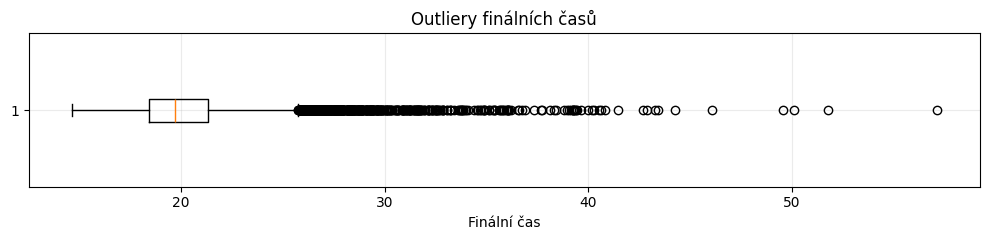

In [72]:
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.boxplot(valid_results["final_time"].dropna(), vert=False)
ax.set_title("Outliery finálních časů")
ax.set_xlabel("Finální čas")
plt.tight_layout()
plt.show()


## Kvalita dat


In [73]:
quality_summary = summarize_data_quality(df_results)
pd.Series(quality_summary)


missing_birth_year_count       6233
missing_fscode_count           6155
missing_team_count                2
missing_attempts_count            0
suspicious_final_time_count     524
duplicate_rows_count              0
dtype: int64

In [74]:
df_results[[
    "athlete_full_name",
    "team",
    "fscode",
    "birth_year",
    "final_time",
    "final_status",
    "has_missing_attempts",
    "suspicious_final_time",
]].head(10)


,athlete_full_name,team,fscode,birth_year,final_time,final_status,has_missing_attempts,suspicious_final_time
0,Patrik Kligl,Běloves,NaN,NaN,15.43,valid,False,False
1,Lukáš Kroupa,Kvasiny B,NaN,NaN,16.01,valid,False,False
2,Jan Zhříval,HZS Hradec Králové,NaN,NaN,16.13,valid,False,False
3,Michal Gierlowski,Tuř,NaN,NaN,17.34,valid,False,False
4,Pavel Hoffman,Běloves,NaN,NaN,17.52,valid,False,False
5,David Hoffman,Běloves,NaN,NaN,17.59,valid,False,False
6,Dominik Mašek,Ruda,NaN,NaN,17.68,valid,False,False
7,Jakub Vondra,Stolín,NaN,NaN,18.19,valid,False,False
8,Stanislav Pavlas,Vidochov,NaN,NaN,18.63,valid,False,False
9,Lukáš Kligl,Běloves,NaN,NaN,18.72,valid,False,False


## Identifikace problémů v datech


In [75]:
possible_duplicate_athletes = find_possible_duplicate_athletes(df_results)
possible_duplicate_athletes.head(20)


,athlete_full_name,team_count,fscode_count,birth_year_count,teams,fs_codes,birth_years,result_count
0,Lukáš Kroupa,6,1,1,"[Kvasiny B, Pardubice - Polabiny, Pardubice- Polabiny, Pardubice-Polabiny, VHJ Pardubice, Zbožnov]",[17681.0],[1997.0],35
1,Šimon Šuba,3,1,1,"[Císařov, Milotice nad Bečvou, Oznice]",[29131.0],[2006.0],33
2,Jakub Mikulík,4,1,1,"[Bludov, Býškovice, Hostinné, SLATINY, Slatiny]",[49721.0],[2004.0],31
3,Matyáš Novák,4,2,2,"[Krouna, Seč, Stará Říše, Výčapy]","[50901.0, 94551.0]","[2006.0, 2007.0]",31
4,Vít Vymazal,4,1,1,"[Morkovice, Oznice, SLATINY, Seč, Slatiny]",[28381.0],[2006.0],30
5,Anna Rajnetová,3,1,1,"[Pardubice Polabiny, Pardubice-Polabiny, Pardubice–Polabiny]",[46242.0],[2007.0],29
6,František Rajnet,4,1,1,"[Pardubice - Polabiny, Pardubice Polabiny, Pardubice-Polabiny, Stéblová]",[61611.0],[2007.0],29
7,Tereza Kroupová,2,1,1,"[CHÁBORY, Chábory, Kvasiny]",[10732.0],[2002.0],29
8,Simona Páralová,1,1,2,[Bořitov],[26472.0],"[2003.0, 2004.0]",27
9,Dominik Andrée,4,1,1,"[Bludov, Kly, Lhenice, PS Mělník]",[48121.0],[2003.0],26


In [76]:
inconsistent_team_names = find_inconsistent_team_names(df_results)
inconsistent_team_names.head(20)


,team_key,variant_count,variants,result_count
0,bukovice,2,"[BUKOVICE, Bukovice]",322
1,slatiny,2,"[SLATINY, Slatiny]",148
2,hzs kraje vysočina,2,"[HZS Kraje Vysočina, HZS kraje Vysočina]",68
3,chábory,2,"[CHÁBORY, Chábory]",58
4,opočno,2,"[OPOČNO, Opočno]",50
5,dubenec,2,"[DUBENEC, Dubenec]",46
6,libňatov,2,"[LIBŇATOV, Libňatov]",39
7,kostelec nad černými lesy,2,"[Kostelec nad Černými Lesy, Kostelec nad Černými lesy]",32
8,dobrá voda,2,"[DOBRÁ VODA, Dobrá Voda]",29
9,havířov-město,2,"[Havířov-Město, Havířov-město]",27


In [77]:
missing_attempts = find_missing_attempts(df_results)
print(f"Počet záznamů s chybějícími nebo nekompletními pokusy: {len(missing_attempts)}")

missing_attempts[[
    "competition_date",
    "discipline",
    "athlete_full_name",
    "team",
    "times",
    "has_missing_attempts",
]].head(20)


Počet záznamů s chybějícími nebo nekompletními pokusy: 0


,competition_date,discipline,athlete_full_name,team,times,has_missing_attempts


## Časový aspekt dat

Tato část ukazuje vývoj objemu dat v čase, sezónnost a případné nerovnoměrné pokrytí datasetu.


In [78]:
results_by_year = (
    df_results.groupby("year")
    .size()
    .rename("result_count")
    .reset_index()
    .sort_values("year")
)

results_by_year


,year,result_count
0,2019,2075
1,2020,729
2,2021,1672
3,2022,2192
4,2023,2475
5,2024,2245
6,2025,2466


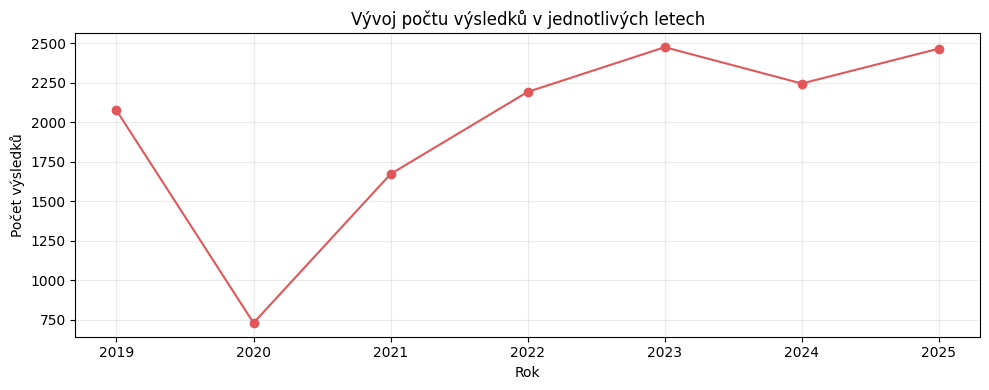

In [79]:
ax = results_by_year.plot(
    kind="line",
    x="year",
    y="result_count",
    marker="o",
    color="#E15759",
    legend=False,
)
ax.set_title("Vývoj počtu výsledků v jednotlivých letech")
ax.set_xlabel("Rok")
ax.set_ylabel("Počet výsledků")
plt.tight_layout()
plt.show()


In [80]:
seasonality = (
    df_results.groupby("month")
    .size()
    .rename("result_count")
    .reset_index()
    .sort_values("month")
)

seasonality


,month,result_count
0,4,105
1,5,1895
2,6,1475
3,7,4995
4,8,4461
5,9,840
6,10,83


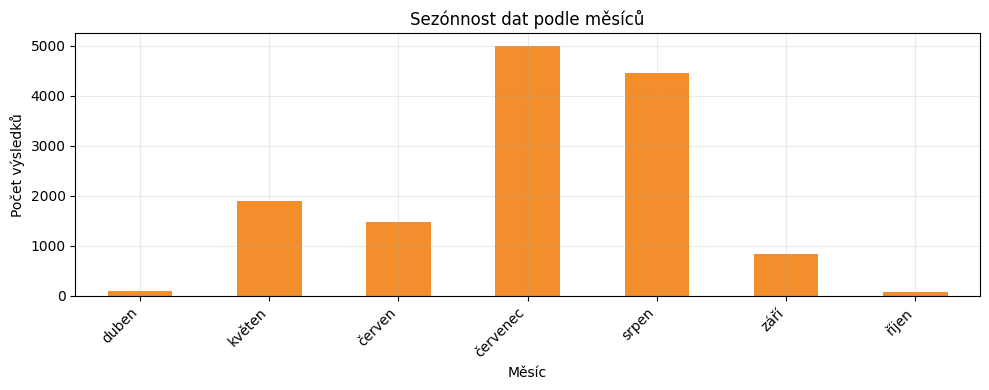

In [81]:
month_labels = {
    1: "leden", 2: "únor", 3: "březen", 4: "duben", 5: "květen", 6: "červen",
    7: "červenec", 8: "srpen", 9: "září", 10: "říjen", 11: "listopad", 12: "prosinec"
}

seasonality_plot = seasonality.copy()
seasonality_plot["month_name"] = seasonality_plot["month"].map(month_labels)

ax = seasonality_plot.plot(
    kind="bar",
    x="month_name",
    y="result_count",
    color="#F28E2B",
    legend=False,
)
ax.set_title("Sezónnost dat podle měsíců")
ax.set_xlabel("Měsíc")
ax.set_ylabel("Počet výsledků")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [82]:
coverage_by_month = (
    df_results.groupby("year_month")
    .size()
    .rename("result_count")
    .reset_index()
    .sort_values("year_month")
)

coverage_by_month.head(24)


,year_month,result_count
0,2019-05,518
1,2019-06,76
2,2019-07,534
3,2019-08,947
4,2020-06,281
5,2020-07,234
6,2020-08,214
7,2021-06,118
8,2021-07,945
9,2021-08,402


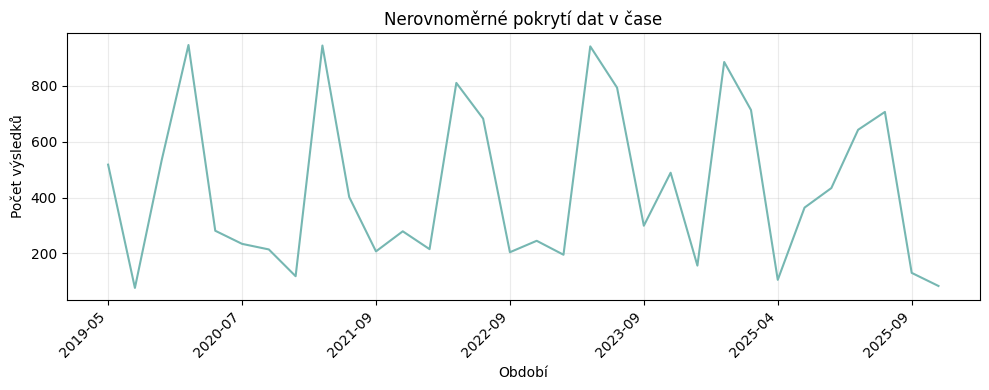

In [83]:
ax = coverage_by_month.plot(
    kind="line",
    x="year_month",
    y="result_count",
    color="#76B7B2",
    legend=False,
)
ax.set_title("Nerovnoměrné pokrytí dat v čase")
ax.set_xlabel("Období")
ax.set_ylabel("Počet výsledků")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [84]:
coverage_summary = pd.Series({
    "year_count": df_results["year"].dropna().nunique(),
    "month_count": df_results["year_month"].replace("NaT", pd.NA).dropna().nunique(),
    "min_results_per_year": results_by_year["result_count"].min() if not results_by_year.empty else None,
    "max_results_per_year": results_by_year["result_count"].max() if not results_by_year.empty else None,
    "min_results_per_month": coverage_by_month["result_count"].min() if not coverage_by_month.empty else None,
    "max_results_per_month": coverage_by_month["result_count"].max() if not coverage_by_month.empty else None,
})

coverage_summary


year_count                  7
month_count                32
min_results_per_year      729
max_results_per_year     2475
min_results_per_month      76
max_results_per_month     947
dtype: int64

In [85]:
least_covered_periods = coverage_by_month.sort_values("result_count").head(12)
most_covered_periods = coverage_by_month.sort_values("result_count", ascending=False).head(12)

print("Nejslabší pokrytí v čase")
display(least_covered_periods)

print("Nejsilnější pokrytí v čase")
display(most_covered_periods)


Nejslabší pokrytí v čase


,year_month,result_count
1,2019-06,76
31,2025-10,83
25,2025-04,105
7,2021-06,118
30,2025-09,130
22,2024-06,156
17,2023-06,195
15,2022-09,204
10,2021-09,207
6,2020-08,214


Nejsilnější pokrytí v čase


,year_month,result_count
3,2019-08,947
8,2021-07,945
18,2023-07,942
23,2024-07,886
13,2022-07,811
19,2023-08,794
24,2024-08,714
29,2025-08,707
14,2022-08,683
28,2025-07,643
